# Wavelets
Everyone knows the Fourier transform where (stationary) signals are represented as a sum of sinusoids, and the standard transform is only localized in frequency. [Wavelets](https://en.wikipedia.org/wiki/Wavelet) on the other hand are localized in both time and frequency. Wavelets have proven to perform well in many ML applications on non-stationary signals. The two main approaches of using wavelets are:
* Discrete wavelet transform (DWT): A signal is broken down into subbands, from which features are extracted and used as input to ML models.
* Continuous wavelet transform (CWT): A scaleogram can be constructed from the signal. The scaleogram can be compared to a spectrogram when using FFT. Scaleogram images can then be used as input to an image classification model.  

In this notebook we will look into how to create scaleograms from bird song signatures.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import matplotlib.image as mpimg
import librosa
import warnings
warnings.filterwarnings('ignore') # get rid of librosa warnings

We could use [PyWavelets](https://pywavelets.readthedocs.io/en/latest/) for the CWT, but here we will use a modified version of [Alexander Neergaard's CWT](https://github.com/aneergaard/CWT). Specifically a parameter is added to allow cutting off the longest wavelets (lowest frequencies).

In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath('../src'))
from cwt import cwt2, rd_file

# Automatic signature extraction
If we calculate the variance of each wavelet vector, we might use that as input to the extraction algorithm.

In [6]:
from IPython.display import Audio
from sklearn.preprocessing import minmax_scale

TRAIN_DIR = '../data/sound/cornell-birdcall/train_audio'
SR = 22050 # sample rate in Hz


In [4]:
# load a file with Black-throated Blue Warbler
d1 = rd_file(TRAIN_DIR+'/btbwar/XC139608.mp3')
Audio(d1, rate=SR)

[ 0.00752671  0.00335862 -0.00043414  0.0002969   0.00372905  0.0003355
 -0.00072162  0.00538915  0.00654816  0.00322049  0.00278071  0.00406738
  0.00515416  0.00235491  0.00151913  0.00258514 -0.00115054 -0.00600466
 -0.00830493 -0.00649001]
[0.05601936 0.04763348 0.04000275 0.04147353 0.04837874 0.04155119
 0.03942436 0.05171875 0.05405058 0.04735556 0.04647076 0.04905944
 0.05124597 0.04561409 0.04393257 0.04607729 0.0385614  0.02879529
 0.02416732 0.0278188 ]


Let's see how that works out for the two files.

In [5]:
# load another file with Black-throated Green Warbler
d2 = rd_file(TRAIN_DIR+'/btnwar/XC135117.mp3')
Audio(d2, rate=SR)

[ 0.00582119 -0.00193867 -0.00127428 -0.00573682 -0.00055661  0.00440413
  0.00135059  0.00378398  0.01029763 -0.00300084 -0.01397939  0.00608761
 -0.00447449 -0.00617238  0.00722413 -0.0034026  -0.00275211  0.00347275
  0.00060292  0.00375473]
[-0.0146634  -0.02463598 -0.02378215 -0.02951718 -0.02285983 -0.01648454
 -0.02040879 -0.01728153 -0.00891052 -0.02600103 -0.04011011 -0.01432101
 -0.0278949  -0.03007693 -0.01286042 -0.02651736 -0.02568137 -0.01768151
 -0.02136966 -0.01731912]


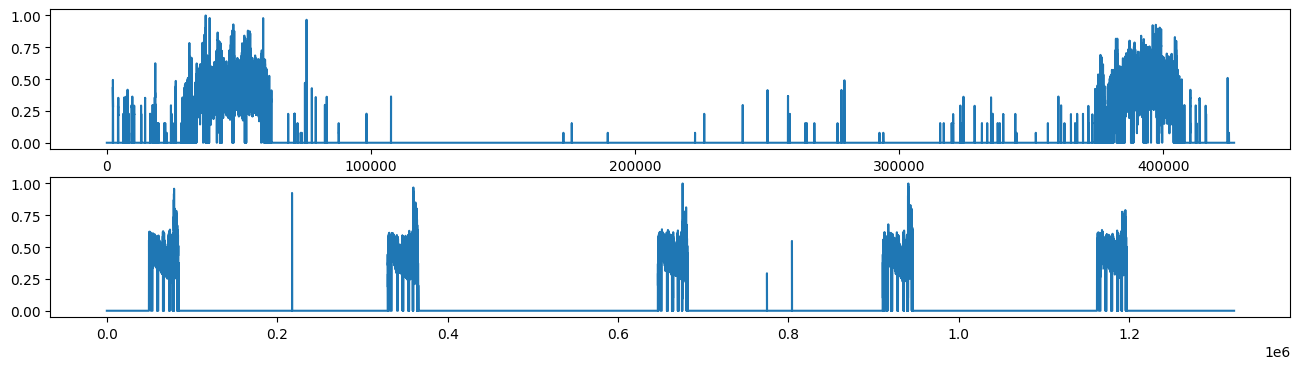

In [6]:
from cwt import calc_var

cs1, f1 = cwt2(d1, nv=12, sr=SR, low_freq=40)
cs2, f2 = cwt2(d2, nv=12, sr=SR, low_freq=40)

fig, axes = plt.subplots(2, 1, figsize=(16,4))
v1 = calc_var(cs1, -30)
axes[0].plot(v1)
v2 = calc_var(cs2, -30)
axes[1].plot(v2)
plt.show()

Scipy has a function find_peaks() that we could use to find high-energy parts of the scaleogram.

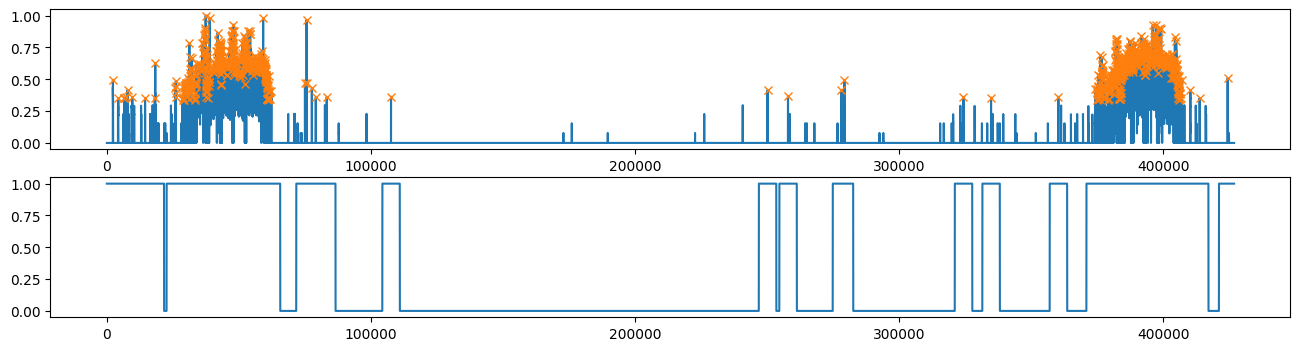

In [7]:
from cwt import find_peaks, mask_sig, get_mask, get_regions

fig, axes = plt.subplots(2, 1, figsize=(16,4))
# peak detection + gliding window
peaks, _ = find_peaks(v1, prominence=0.3)
axes[0].plot(v1)
axes[0].plot(peaks, v1[peaks], "x")
m = mask_sig(len(v1), peaks, SR, 0.3)
axes[1].plot(m)
plt.show()

Next, we extract the mask segments with other Scipy functions:

In [8]:
mask = get_mask(v1, prom=0.3, dur=0.2, sr=SR)
df = get_regions(mask, SR, 'btbwar', 'XC139608.mp3')
df.head(6)

,Start,End,Duration,Species,File
0,91,11853,0.533,btbwar,XC139608.mp3
1,12290,20546,0.374,btbwar,XC139608.mp3
2,23715,64523,1.851,btbwar,XC139608.mp3
3,72804,85463,0.574,btbwar,XC139608.mp3
4,105397,109807,0.200,btbwar,XC139608.mp3
5,247948,252358,0.200,btbwar,XC139608.mp3


We are only interested in segments of a certain length, say 1s or more:

In [9]:
df = df[df.Duration >= 1.0]
df = df.reset_index(drop=True)
df

,Start,End,Duration,Species,File
0,23715,64523,1.851,btbwar,XC139608.mp3
1,371982,415979,1.995,btbwar,XC139608.mp3


Plot those regions to check that we captured the signatures:

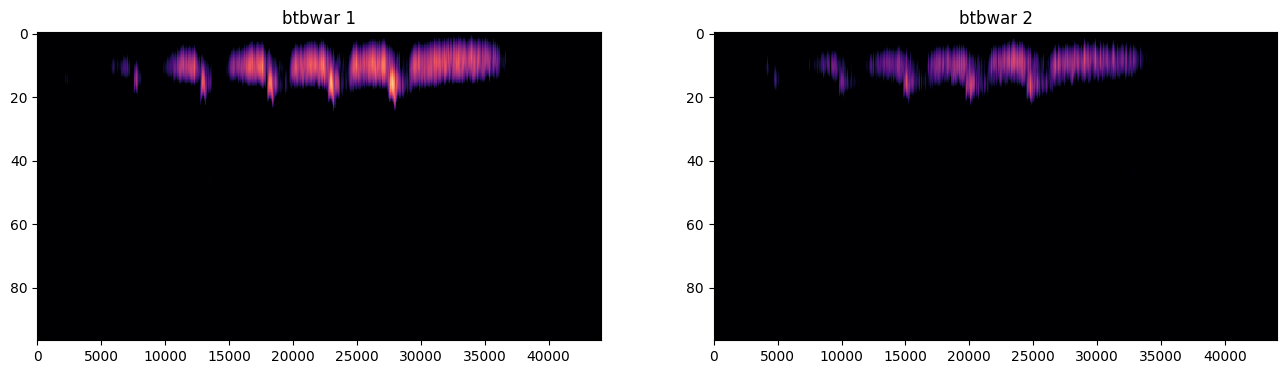

In [10]:
from cwt import plot_sigx2

# we plot two seconds
plot_sigx2(d1[df.Start[0]:df.Start[0]+2*SR], d1[df.Start[1]:df.Start[1]+2*SR], 
           name1='btbwar 1', name2='btbwar 2')

Not bad at all! Let's try the other file:

In [11]:
mask = get_mask(v2, prom=0.3, dur=0.3, sr=SR)
df = get_regions(mask, SR, 'btnwar', 'XC135117.mp3')
df = df[df.Duration >= 1.0]
df = df.reset_index(drop=True)
df

,Start,End,Duration,Species,File
0,46565,87345,1.849,btnwar,XC135117.mp3
1,343466,368571,1.139,btnwar,XC135117.mp3
2,643464,684803,1.875,btnwar,XC135117.mp3
3,907394,949235,1.898,btnwar,XC135117.mp3
4,1160603,1199959,1.785,btnwar,XC135117.mp3


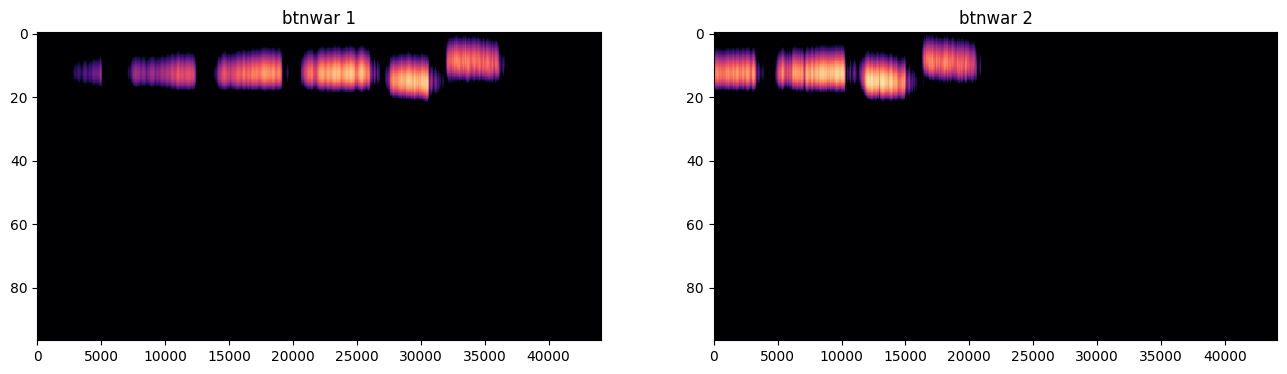

In [12]:
plot_sigx2(d2[df.Start[0]:df.Start[0]+2*SR], d2[df.Start[1]:df.Start[1]+2*SR], 
           name1='btnwar 1', name2='btnwar 2')

The second signature is clipped a bit, but that is OK. All five signatures were detected. The final step is to combine everything into a function that will extract signatures from a file and dump them as jpeg images.

A rule-based signature extraction algorithm is pretty much doomed on complex or noisy signals. A better solution is to train a binary classifier to extract signatures on a reasonable scale (1-5s), and then feed the extracted signatures to a species classifier. Breaking this problem down into two steps simplifies things a lot, and each step can be optimized independently. 

In [13]:
# free up memory
%xdel d1
%xdel d2
%xdel cs1
%xdel cs2

# Create images

Process a few files and see what we get.

In [2]:
OUT_DIR = './tmp'
%mkdir {OUT_DIR}


In [18]:
from cwt import batch_extract, scaleo_extract

flist = ['/btbwar/XC139608.mp3', '/btbwar/XC51863.mp3', '/btbwar/XC134502.mp3', '/btbwar/XC415596.mp3']
plist = [ f'{TRAIN_DIR}{f}' for f in flist ]

batch_extract(plist, OUT_DIR)

# 47.2s
# for i in plist:
#     scaleo_extract(i, outdir='./tmp')

[ 0.00752671  0.00335862 -0.00043414  0.0002969   0.00372905  0.0003355
 -0.00072162  0.00538915  0.00654816  0.00322049  0.00278071  0.00406738
  0.00515416  0.00235491  0.00151913  0.00258514 -0.00115054 -0.00600466
 -0.00830493 -0.00649001]
[0.05601936 0.04763348 0.04000275 0.04147353 0.04837874 0.04155119
 0.03942436 0.05171875 0.05405058 0.04735556 0.04647076 0.04905944
 0.05124597 0.04561409 0.04393257 0.04607729 0.0385614  0.02879529
 0.02416732 0.0278188 ]
[-0.00314536 -0.00663371 -0.00763499 -0.00686846 -0.00898153 -0.0057534
  0.00387361  0.00589353  0.00196177  0.00116689 -0.00264478 -0.00814265
 -0.00562211 -0.00254453 -0.00551121 -0.00599885 -0.00312959 -0.00283378
 -0.00235678  0.00126918]
[-0.00213661 -0.01221277 -0.015105   -0.01289088 -0.0189945  -0.00966998
  0.01813779  0.02397236  0.01261542  0.0103194  -0.00069068 -0.01657138
 -0.00929076 -0.00040112 -0.00897041 -0.01037899 -0.00209108 -0.00123661
  0.00014121  0.01061485]
[-5.8390611e-05 -8.6227476e-05  2.8102790e

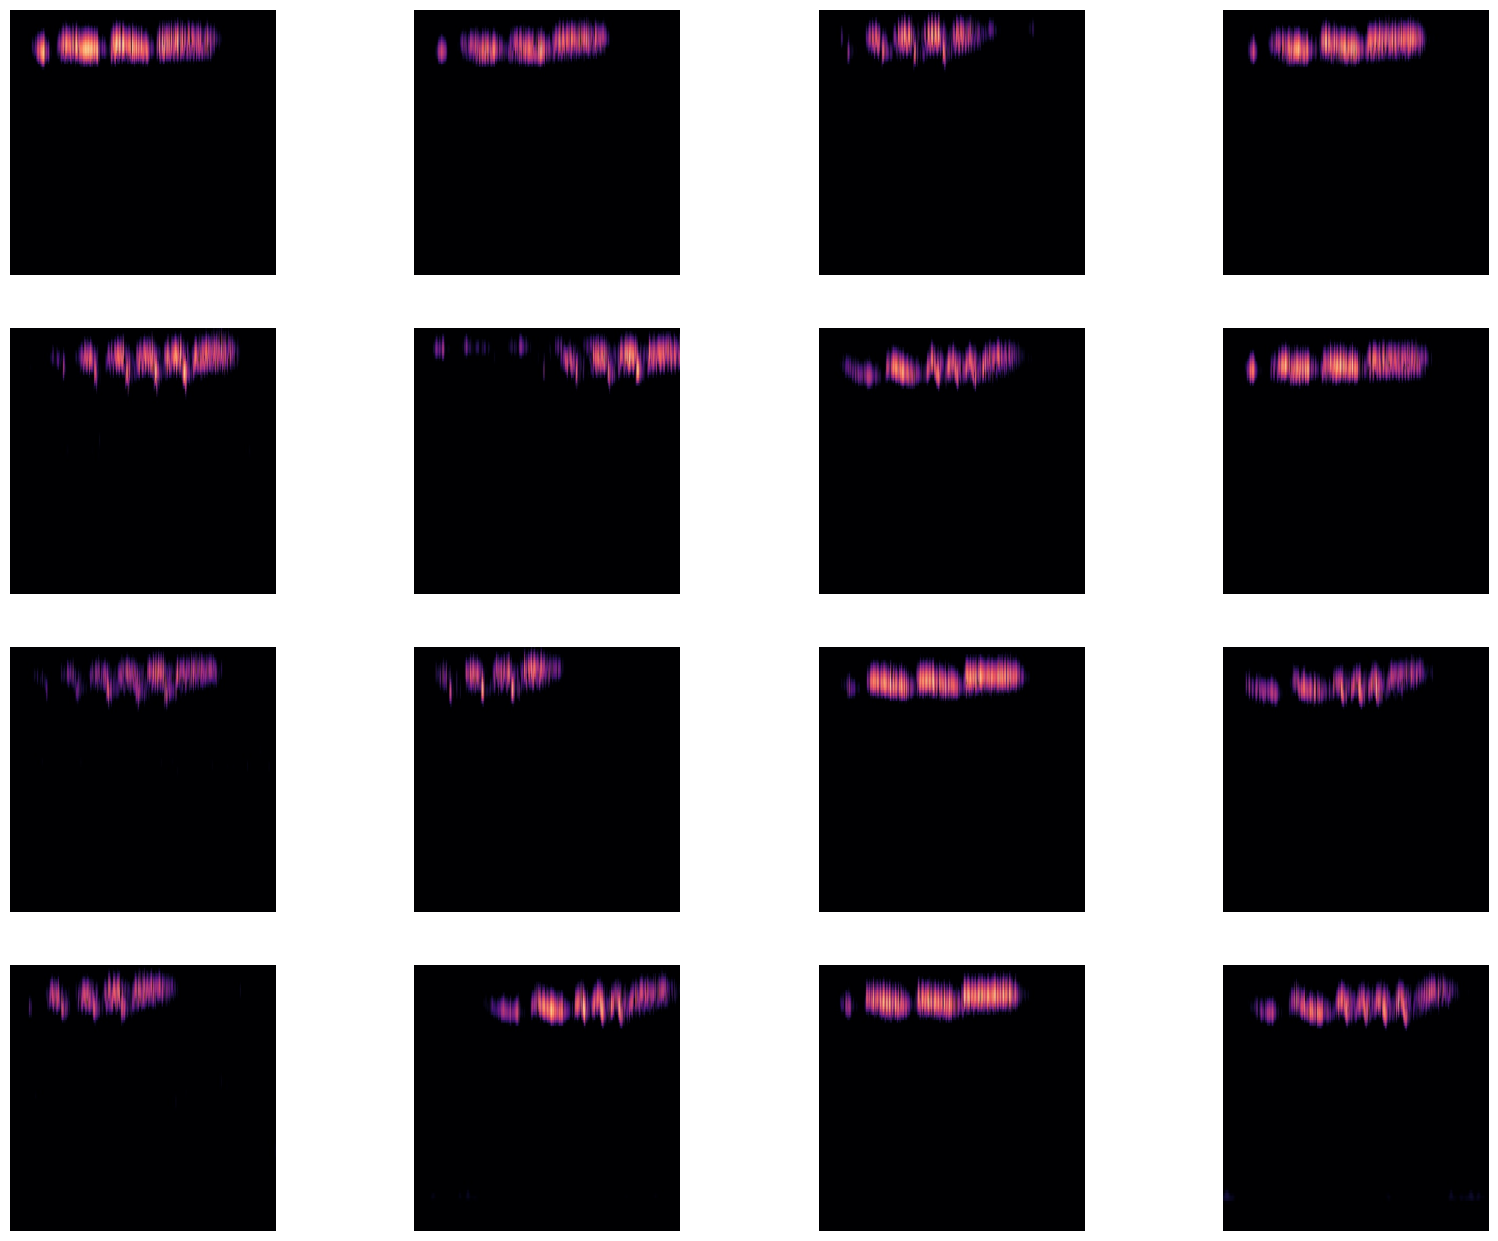

In [7]:
import glob

images = glob.glob(OUT_DIR + "/btbwar*.jpg")
plt.figure(figsize=(20,20))
columns = 4
for i, image in enumerate(images):
    plt.subplot(len(images) // columns + 1, columns, i + 1)
    plt.imshow(mpimg.imread(image))
    plt.axis('off')

Now, another warbler.

In [8]:
flist = ['/btnwar/XC135117.mp3', '/btnwar/XC135495.mp3', '/btnwar/XC173264.mp3', '/btnwar/XC501261.mp3', '/btnwar/XC486860.mp3']
# for i in flist:
#     scaleo_extract(TRAIN_DIR+i, outdir='./tmp')
plist = [ f'{TRAIN_DIR}{f}' for f in flist ]

batch_extract(plist, OUT_DIR)

[ 2.3542745e-03  5.0131342e-04  2.0877489e-05 -1.9345699e-03
 -4.0360924e-04  4.2092027e-03  3.3361285e-03  1.6638678e-03
  4.7865612e-03  4.6980833e-03  4.3048933e-03  5.4689208e-03
  3.1617049e-03  1.4575364e-03 -1.0137939e-03 -3.5046772e-04
  3.4689340e-03  4.7648214e-03  7.0764194e-03  6.6427924e-03]
[-0.0205948  -0.02272528 -0.02327767 -0.02552599 -0.02376574 -0.01846205
 -0.01946589 -0.02138861 -0.01779822 -0.01789995 -0.01835203 -0.01701367
 -0.01966644 -0.02162584 -0.02446731 -0.02370463 -0.01931319 -0.01782322
 -0.01516541 -0.01566398]
[ 0.00582119 -0.00193867 -0.00127428 -0.00573682 -0.00055661  0.00440413
  0.00135059  0.00378398  0.01029763 -0.00300084 -0.01397939  0.00608761
 -0.00447449 -0.00617238  0.00722413 -0.0034026  -0.00275211  0.00347275
  0.00060292  0.00375473]
[-0.0146634  -0.02463598 -0.02378215 -0.02951718 -0.02285983 -0.01648454
 -0.02040879 -0.01728153 -0.00891052 -0.02600103 -0.04011011 -0.01432101
 -0.0278949  -0.03007693 -0.01286042 -0.02651736 -0.025681

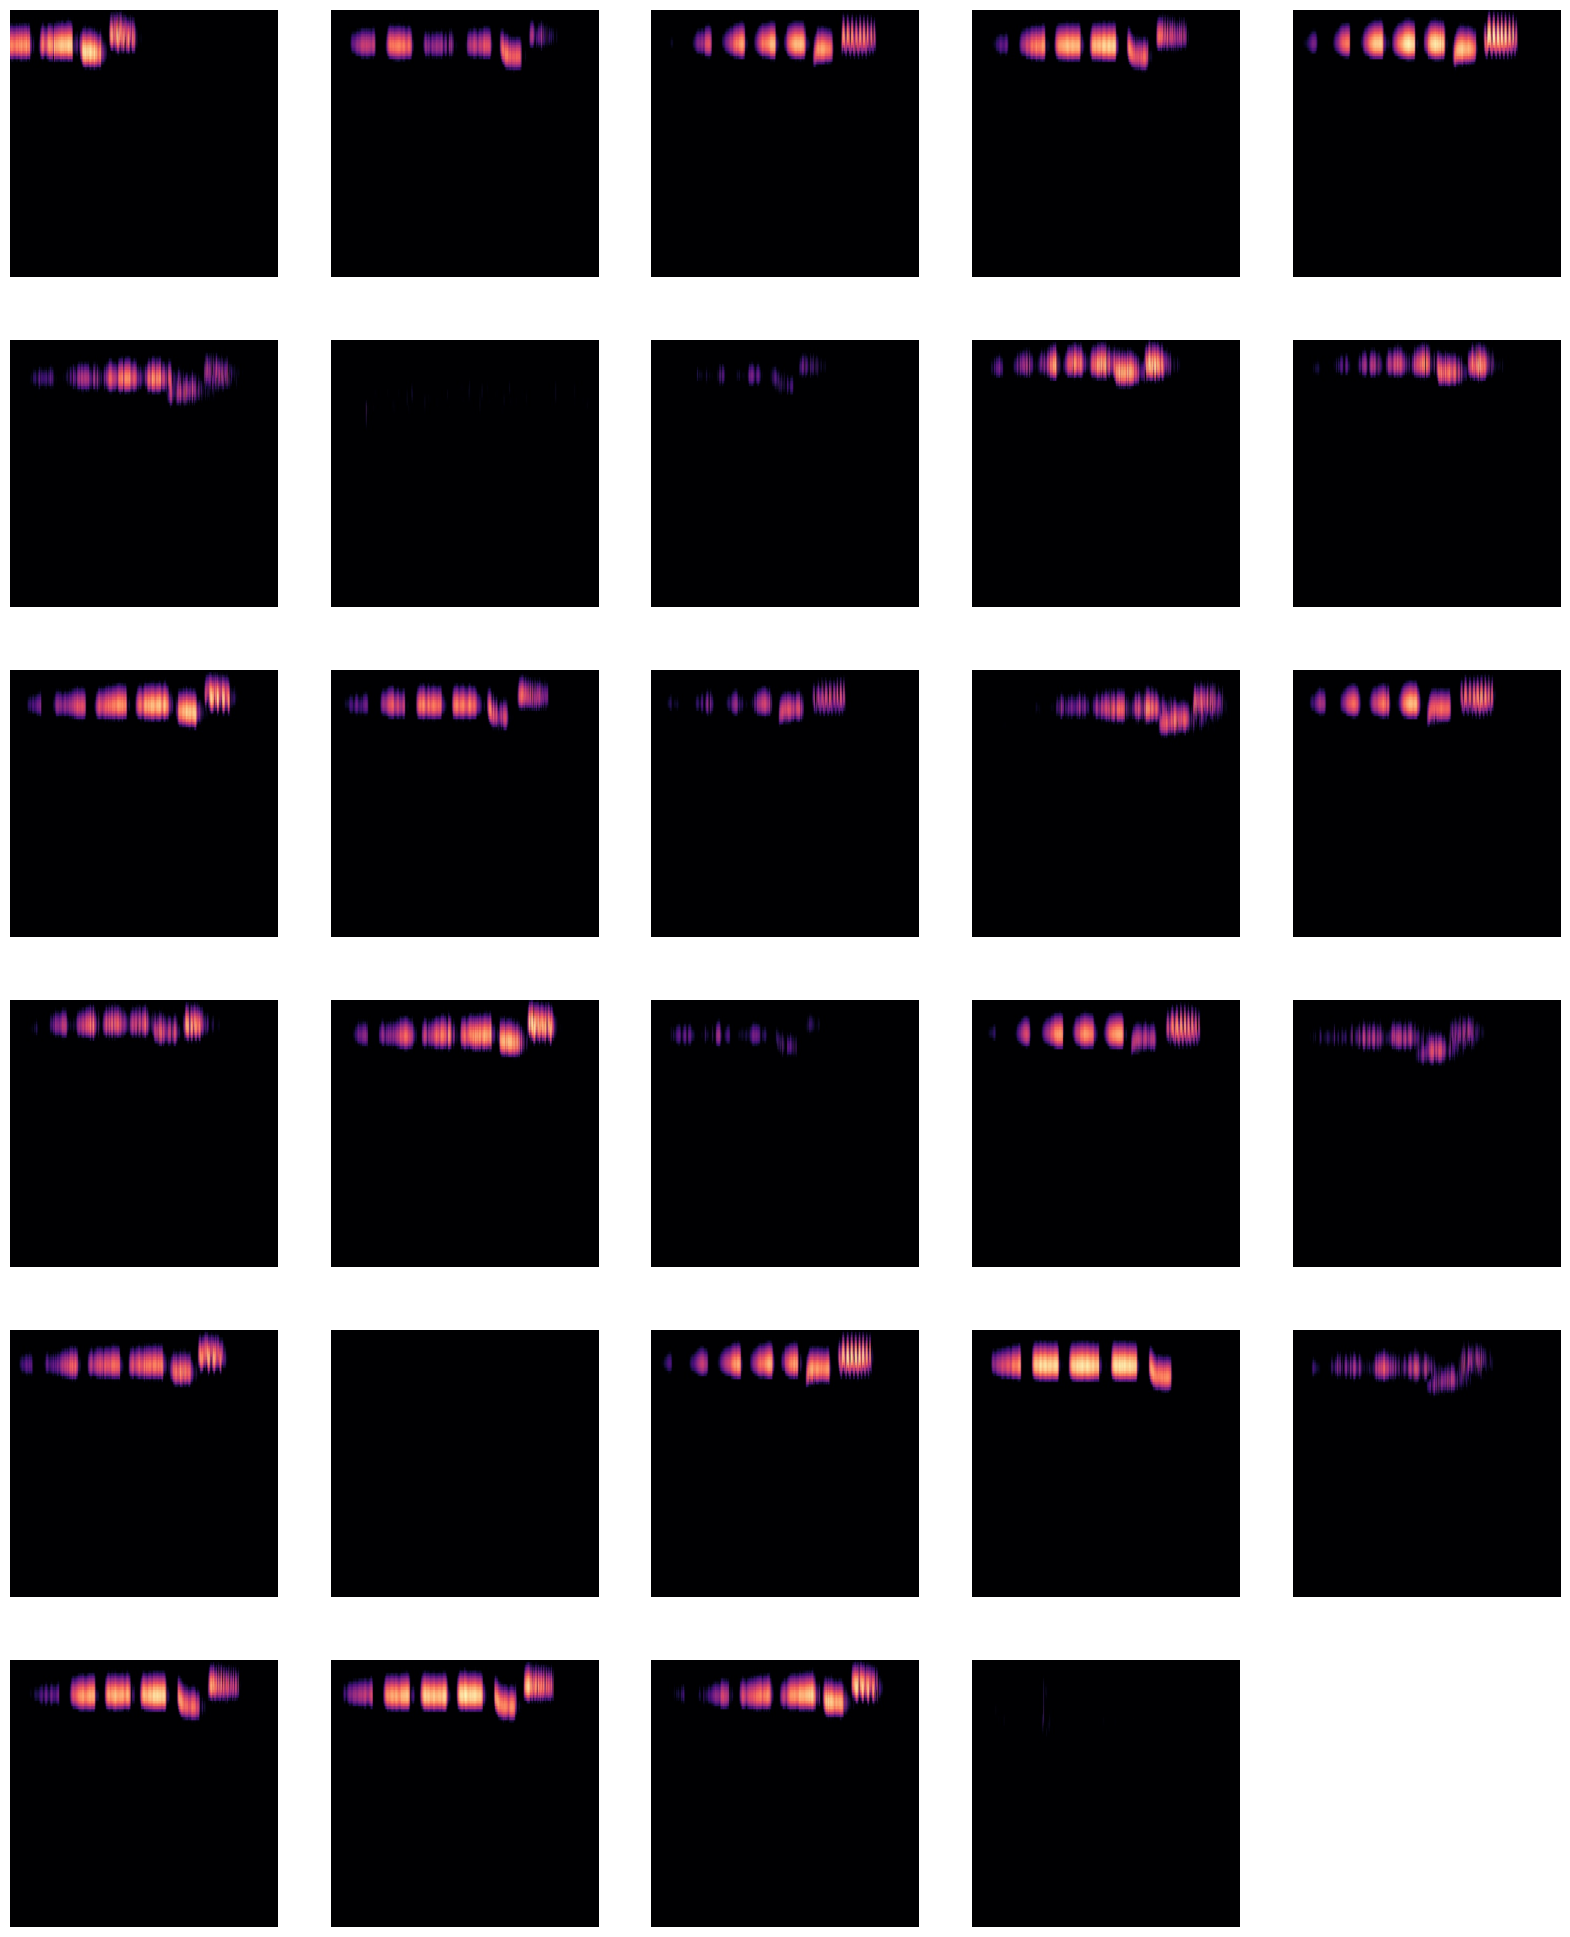

In [19]:
images = glob.glob(OUT_DIR + "/btnwar*.jpg")
plt.figure(figsize=(20,25))
columns = 5
for i, image in enumerate(images):
    plt.subplot(len(images) // columns + 1, columns, i + 1)
    plt.imshow(mpimg.imread(image))
    plt.axis('off')

We extracted 4 non-signatures from file XC501261 - should not be a problem to do a post check to detect and remove false signatures. Or better: Train an ML model (binary classifier) to detect signatures.

# Color or grayscale?
The scaleograms represent magnitude of the wavelet coefficients. Pseudo-coloring is used here for human perception. But there is really not more information here than in a grayscale image. Which colormap to use for training? Well, if we think of augmentation with brightness or contrast adjustments, those are only "correct" for grayscale. On the other hand, image models might train better with color inputs... So maybe we need to try both - or even an ensemble of the two!

# Summary
This notebook shows how to use the contiunous wavelet transform to create scaleograms from non-stationary audio signals, with the purpose of using an image classifier to detect bird species. The outline of a two-stage ML pipeline is starting to emerge:  
* Step 1: Train a binary classifier to detect and extract bird songs on a reasonable scale (1-5s)
* Step 2: Feed the bird song segments to a species classifier  

All using the wavelet transform and scaleograms of course.

In [3]:
!rm -fr {OUT_DIR}